# Reto 02 — Comparación de algoritmos para Multi-Armed Bandits

**Integrantes:** Camilo Zapata Cárdenas  
**Correos:** camilo.zapata97@eia.edu.co  
**Fecha:** 2026-08-02

## Objetivo

Comparar estrategias de selección de acciones para un problema estacionario de Multi-Armed Bandits mediante recompensa, selección del brazo óptimo y pseudo-regret.

## 1. Preparación del entorno

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from challenges.challenge_02_bandit_algorithms.starter_code import (
    GaussianBandit,
    cumulative_average,
    cumulative_regret,
    optimal_action_rate,
)

SEED = 2026
HORIZON = 1_000
N_RUNS = 100
MEANS = np.array([1.0, 2.0, 1.5])
STDS = np.array([0.5, 0.5, 1.5])
ARM_NAMES = np.array(["A1", "A2", "A3"])

## 2. Verificación del bandit

Crea el entorno, muestra sus propiedades y explica por qué A2 es el brazo óptimo.

In [2]:
bandit = GaussianBandit(MEANS, STDS, seed=SEED)

environment_summary = pd.Series({
    "Número de brazos": bandit.n_arms,
    "Brazo óptimo": ARM_NAMES[bandit.optimal_arm],
    "Media óptima": bandit.optimal_mean,
})
display(environment_summary)

sample_rewards = pd.Series(
    {arm: bandit.pull(index) for index, arm in enumerate(ARM_NAMES)},
    name="Recompensa de muestra",
)
sample_rewards

Número de brazos      3
Brazo óptimo         A2
Media óptima        2.0
dtype: object

A1    0.603439
A2    2.120286
A3   -1.344490
Name: Recompensa de muestra, dtype: float64

El brazo óptimo es el A2 ya que es el que tiene una mejor recompensa media y menor desviación estándar (igual a la de A1)

## 3. Funciones auxiliares

Implementa actualización incremental y selección aleatoria entre empates.

In [3]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    maximum = np.max(values)
    candidates = np.flatnonzero(values == maximum)
    return int(rng.choice(candidates))


def incremental_update(estimate: float, reward: float, count: int) -> float:
    return estimate + (reward - estimate) / count


def validate_horizon(horizon: int) -> None:
    if not isinstance(horizon, int) or isinstance(horizon, bool) or horizon <= 0:
        raise ValueError("horizon debe ser un entero positivo.")


def history_row(step: int, action: int, reward: float, q_values: np.ndarray) -> dict[str, float | int]:
    return {
        "step": step,
        "action": action,
        "reward": reward,
        **{f"q_{arm.lower()}": q_values[index] for index, arm in enumerate(ARM_NAMES)},
    }

## 4. ε-greedy

In [4]:
def run_epsilon_greedy(
    *, epsilon: float, initial_value: float, horizon: int, seed: int
) -> pd.DataFrame:
    if not 0.0 <= epsilon <= 1.0:
        raise ValueError("epsilon debe estar entre 0 y 1.")
    validate_horizon(horizon)

    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    q_values = np.full(bandit.n_arms, float(initial_value))
    counts = np.zeros(bandit.n_arms, dtype=int)
    rows = []

    for step in range(1, horizon + 1):
        if rng.random() < epsilon:
            action = int(rng.integers(bandit.n_arms))
        else:
            action = random_argmax(q_values, rng)

        observed_reward = bandit.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(
            q_values[action], observed_reward, counts[action]
        )
        rows.append(history_row(step, action, observed_reward, q_values))

    return pd.DataFrame(rows)

## 5. ε-greedy con inicio optimista

Reutiliza la implementación anterior con ε = 0 y Q0 = 5. Explica el mecanismo de exploración.

In [5]:
optimistic_example = run_epsilon_greedy(
    epsilon=0.0, initial_value=5.0, horizon=20, seed=SEED
)
optimistic_example

,step,action,reward,q_a1,q_a2,q_a3
0,1,0,0.603439,0.603439,5.000000,5.000000
1,2,2,1.860857,0.603439,5.000000,1.860857
2,3,1,1.051837,0.603439,1.051837,1.860857
3,4,2,3.593658,0.603439,1.051837,2.727257
4,5,2,2.457442,0.603439,1.051837,2.637319
5,6,2,1.061929,0.603439,1.051837,2.243471
6,7,2,1.032076,0.603439,1.051837,2.001192
7,8,2,1.955753,0.603439,1.051837,1.993619
8,9,2,1.098510,0.603439,1.051837,1.865746
9,10,2,1.161137,0.603439,1.051837,1.777670


El mecanismo de exploración con un inicio optimista funciona de la siguiente manera:

- Primero elije aleatoriamente, ya que todos empiezan con la misma recompensa de Q0, que en este caso es 5, a la máquina elegida le actualiza el valor, que va a ser menor a ese Q0.
- En la siguiente iteración, sí o sí va a explotar ya que el ε = 0, lo bueno es que en esta siguiente iteración irá a otra máquina, garantizando que las 3 se exploren inicialmente de manera constante y por ende en ciertos escenarios va a converger más rápido al valor real, aunque yo en lo personal si recomendaría tener un ε > 0, para no 'perder' tiempo en posibles resultados aleatorios altos (una buena racha) de una máquina no óptima ya que siempre va a explotar.

## 6. UCB

In [6]:
def run_ucb(*, c: float, horizon: int, seed: int) -> pd.DataFrame:
    if c < 0:
        raise ValueError("c debe ser mayor o igual que 0.")
    validate_horizon(horizon)

    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    q_values = np.zeros(bandit.n_arms, dtype=float)
    counts = np.zeros(bandit.n_arms, dtype=int)
    rows = []

    for step in range(1, horizon + 1):
        untried = np.flatnonzero(counts == 0)
        if untried.size:
            action = int(rng.choice(untried))
        else:
            confidence = c * np.sqrt(np.log(step) / counts)
            action = random_argmax(q_values + confidence, rng)

        observed_reward = bandit.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(
            q_values[action], observed_reward, counts[action]
        )
        rows.append(history_row(step, action, observed_reward, q_values))

    return pd.DataFrame(rows)

## 7. Softmax

In [7]:
def run_softmax(*, temperature: float, horizon: int, seed: int) -> pd.DataFrame:
    if temperature <= 0:
        raise ValueError("temperature debe ser estrictamente positiva.")
    validate_horizon(horizon)

    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    q_values = np.zeros(bandit.n_arms, dtype=float)
    counts = np.zeros(bandit.n_arms, dtype=int)
    rows = []

    for step in range(1, horizon + 1):
        logits = q_values / temperature
        weights = np.exp(logits - np.max(logits))
        probabilities = weights / weights.sum()
        action = int(rng.choice(bandit.n_arms, p=probabilities))

        observed_reward = bandit.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(
            q_values[action], observed_reward, counts[action]
        )
        rows.append(history_row(step, action, observed_reward, q_values))

    return pd.DataFrame(rows)

## 8. Pruebas pequeñas

Verifica longitud, acciones válidas, conteos y reproducibilidad antes del experimento completo.

In [8]:
SMALL_HORIZON = 30
small_algorithms = {
    "epsilon_greedy": lambda seed: run_epsilon_greedy(
        epsilon=0.10, initial_value=0.0, horizon=SMALL_HORIZON, seed=seed
    ),
    "optimistic": lambda seed: run_epsilon_greedy(
        epsilon=0.0, initial_value=5.0, horizon=SMALL_HORIZON, seed=seed
    ),
    "ucb": lambda seed: run_ucb(c=2.0, horizon=SMALL_HORIZON, seed=seed),
    "softmax": lambda seed: run_softmax(
        temperature=0.20, horizon=SMALL_HORIZON, seed=seed
    ),
}

for name, run_algorithm in small_algorithms.items():
    first = run_algorithm(SEED)
    second = run_algorithm(SEED)
    other_seed = run_algorithm(SEED + 1)
    assert len(first) == SMALL_HORIZON
    assert first["action"].between(0, len(MEANS) - 1).all()
    assert first["action"].value_counts().sum() == SMALL_HORIZON
    pd.testing.assert_frame_equal(first, second)
    assert not first.equals(other_seed)

print("Pruebas pequeñas superadas para los cuatro algoritmos.")

Pruebas pequeñas superadas para los cuatro algoritmos.


## 9. Comparación principal

Ejecuta 100 corridas de 1.000 pasos por algoritmo. Agrega las curvas y reporta su variabilidad.

In [9]:
BASE_ALGORITHMS = {
    "ε-greedy": lambda seed: run_epsilon_greedy(
        epsilon=0.10, initial_value=0.0, horizon=HORIZON, seed=seed
    ),
    "Inicio optimista": lambda seed: run_epsilon_greedy(
        epsilon=0.0, initial_value=5.0, horizon=HORIZON, seed=seed
    ),
    "UCB": lambda seed: run_ucb(c=2.0, horizon=HORIZON, seed=seed),
    "Softmax": lambda seed: run_softmax(
        temperature=0.20, horizon=HORIZON, seed=seed
    ),
}

def run_experiment(algorithms: dict[str, object], n_runs: int) -> dict[str, dict[str, np.ndarray]]:
    results = {}
    optimal_arm = int(np.argmax(MEANS))

    for name, run_algorithm in algorithms.items():
        cumulative_rewards = np.empty((n_runs, HORIZON))
        cumulative_averages = np.empty((n_runs, HORIZON))
        optimal_rates = np.empty((n_runs, HORIZON))
        regrets = np.empty((n_runs, HORIZON))
        action_counts = np.empty((n_runs, len(MEANS)))
        final_window_rewards = np.empty(n_runs)

        for run_index in range(n_runs):
            history = run_algorithm(SEED + run_index)
            rewards = history["reward"].to_numpy()
            actions = history["action"].to_numpy(dtype=int)
            cumulative_rewards[run_index] = np.cumsum(rewards)
            cumulative_averages[run_index] = cumulative_average(rewards)
            optimal_rates[run_index] = optimal_action_rate(actions, optimal_arm)
            regrets[run_index] = cumulative_regret(actions, MEANS)
            action_counts[run_index] = np.bincount(actions, minlength=len(MEANS))
            final_window_rewards[run_index] = rewards[-100:].mean()

        results[name] = {
            "cumulative_reward": cumulative_rewards,
            "cumulative_average": cumulative_averages,
            "optimal_rate": optimal_rates,
            "regret": regrets,
            "action_counts": action_counts,
            "last_100_reward": final_window_rewards,
        }

    return results

results = run_experiment(BASE_ALGORITHMS, N_RUNS)
print(f"Corridas completadas: {N_RUNS} por algoritmo; horizonte: {HORIZON} pasos.")

Corridas completadas: 100 por algoritmo; horizonte: 1000 pasos.


## 10. Tabla resumen y visualizaciones

Incluye recompensa, acción óptima, regret y distribución final de acciones.

,Recompensa total promedio,Recompensa promedio últimos 100 pasos,Porcentaje final de acción óptima,Regret acumulado final
Algoritmo,,,,
ε-greedy,1933.679,1.950,90.597,66.900
Inicio optimista,1975.359,1.979,95.199,24.770
UCB,1950.723,1.984,92.289,48.850
Softmax,1877.582,1.921,78.131,124.015


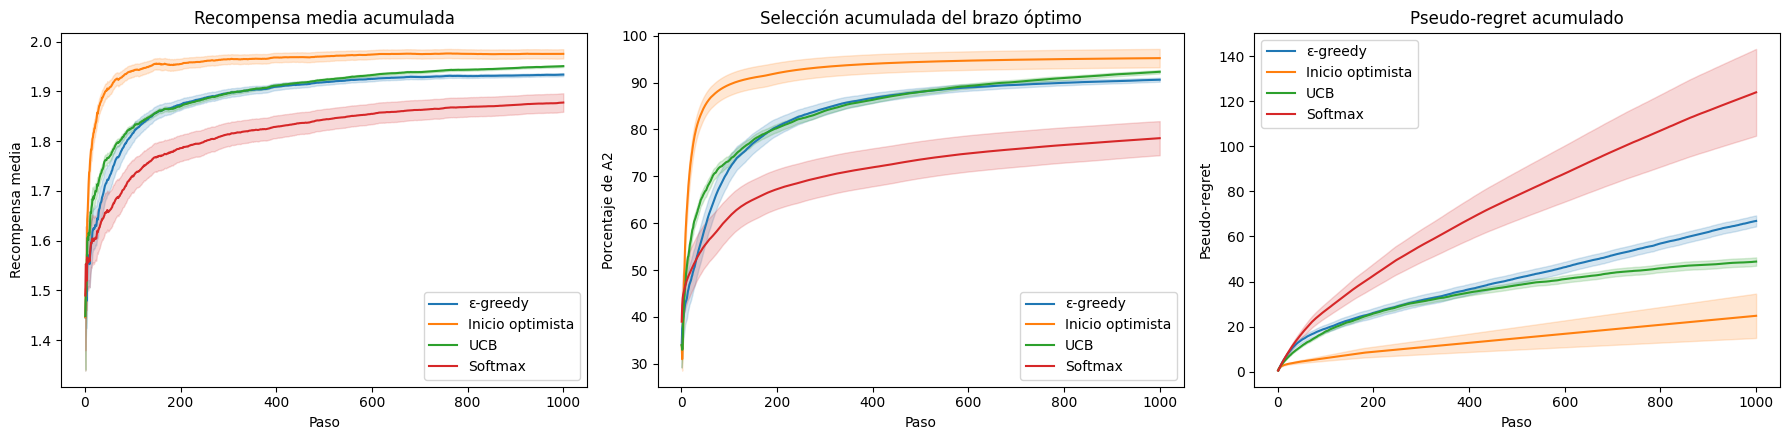

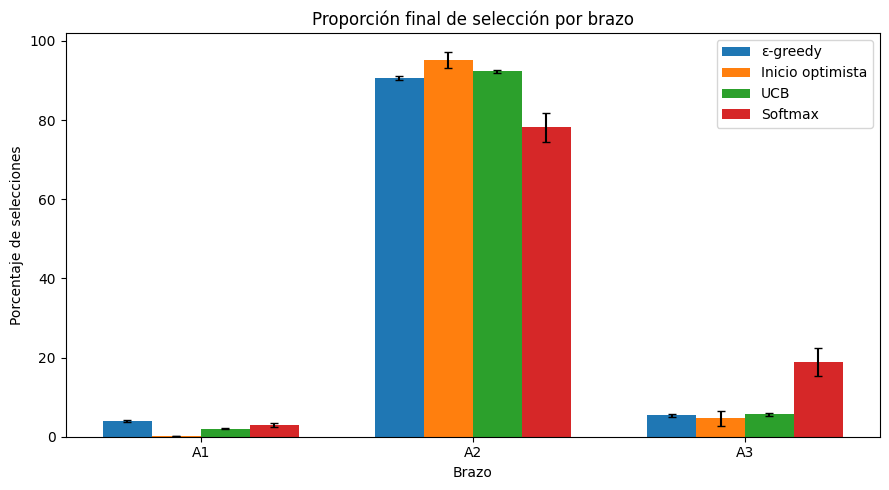

In [10]:
summary_rows = []
for name, metrics in results.items():
    summary_rows.append({
        "Algoritmo": name,
        "Recompensa total promedio": metrics["cumulative_reward"][:, -1].mean(),
        "Recompensa promedio últimos 100 pasos": metrics["last_100_reward"].mean(),
        "Porcentaje final de acción óptima": metrics["optimal_rate"][:, -1].mean(),
        "Regret acumulado final": metrics["regret"][:, -1].mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Algoritmo")
display(summary_df.round(3))

colors = {
    "ε-greedy": "tab:blue",
    "Inicio optimista": "tab:orange",
    "UCB": "tab:green",
    "Softmax": "tab:red",
}
steps = np.arange(1, HORIZON + 1)

def plot_curve(ax, metric: str, title: str, ylabel: str) -> None:
    for name, color in colors.items():
        data = results[name][metric]
        mean = data.mean(axis=0)
        sem = data.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
        ax.plot(steps, mean, label=name, color=color)
        ax.fill_between(steps, mean - sem, mean + sem, color=color, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("Paso")
    ax.set_ylabel(ylabel)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_curve(axes[0], "cumulative_average", "Recompensa media acumulada", "Recompensa media")
plot_curve(axes[1], "optimal_rate", "Selección acumulada del brazo óptimo", "Porcentaje de A2")
plot_curve(axes[2], "regret", "Pseudo-regret acumulado", "Pseudo-regret")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(ARM_NAMES))
width = 0.18
for offset, (name, color) in enumerate(colors.items()):
    proportions = results[name]["action_counts"] / HORIZON * 100
    means = proportions.mean(axis=0)
    sems = proportions.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    ax.bar(positions + (offset - 1.5) * width, means, width, yerr=sems, label=name, color=color, capsize=3)
ax.set_xticks(positions)
ax.set_xticklabels(ARM_NAMES)
ax.set_title("Proporción final de selección por brazo")
ax.set_xlabel("Brazo")
ax.set_ylabel("Porcentaje de selecciones")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Sensibilidad de hiperparámetros

Compara los valores de ε, Q0, c y τ indicados en el enunciado.

,Algoritmo,Parámetro,Valor,Recompensa promedio,Porcentaje final de acción óptima,Regret acumulado final
0,ε-greedy,ε,0.01,1.825,79.290,177.533
1,ε-greedy,ε,0.10,1.935,89.553,71.900
2,ε-greedy,ε,0.30,1.848,79.197,154.650
3,Inicio optimista,Q0,2.00,1.953,89.660,52.250
4,Inicio optimista,Q0,5.00,1.965,92.260,39.267
5,Inicio optimista,Q0,10.00,1.965,92.260,39.267
6,UCB,c,0.50,1.997,98.910,6.650
7,UCB,c,1.00,1.988,97.420,16.033
8,UCB,c,2.00,1.959,93.220,43.783
9,Softmax,τ,0.05,1.741,63.297,266.850


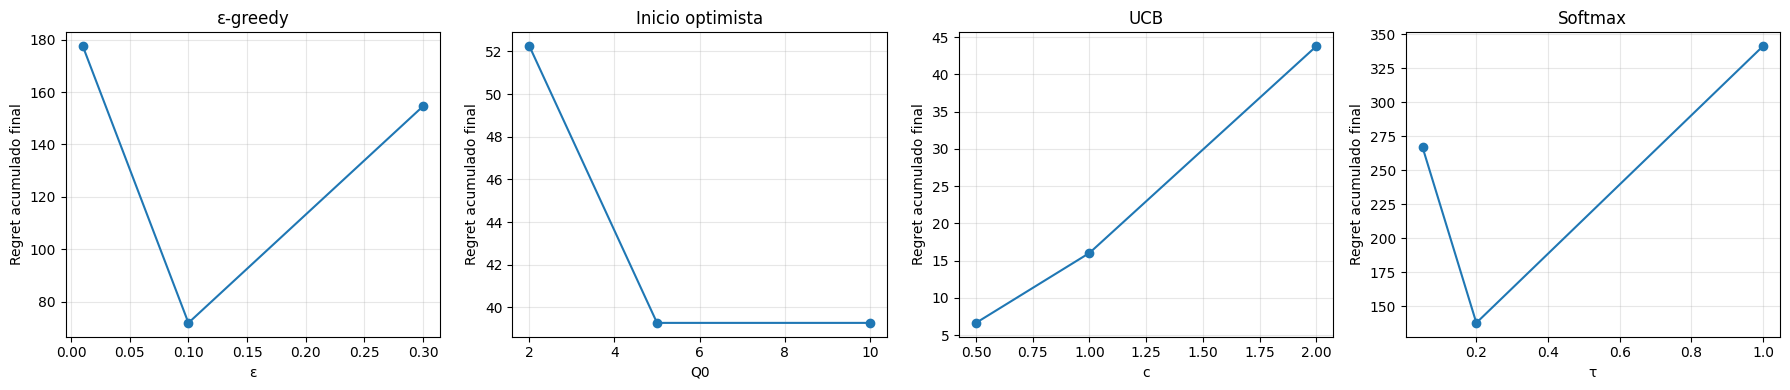

In [11]:
SENSITIVITY_RUNS = 30

def evaluate_configuration(run_algorithm: object) -> dict[str, float]:
    rewards = []
    optimal_rates = []
    regrets = []
    optimal_arm = int(np.argmax(MEANS))

    for run_index in range(SENSITIVITY_RUNS):
        history = run_algorithm(SEED + run_index)
        actions = history["action"].to_numpy(dtype=int)
        values = history["reward"].to_numpy()
        rewards.append(values.mean())
        optimal_rates.append(optimal_action_rate(actions, optimal_arm)[-1])
        regrets.append(cumulative_regret(actions, MEANS)[-1])

    return {
        "Recompensa promedio": float(np.mean(rewards)),
        "Porcentaje final de acción óptima": float(np.mean(optimal_rates)),
        "Regret acumulado final": float(np.mean(regrets)),
    }

sensitivity_configs = [
    ("ε-greedy", "ε", value, lambda seed, value=value: run_epsilon_greedy(epsilon=value, initial_value=0.0, horizon=HORIZON, seed=seed))
    for value in [0.01, 0.10, 0.30]
] + [
    ("Inicio optimista", "Q0", value, lambda seed, value=value: run_epsilon_greedy(epsilon=0.0, initial_value=value, horizon=HORIZON, seed=seed))
    for value in [2.0, 5.0, 10.0]
] + [
    ("UCB", "c", value, lambda seed, value=value: run_ucb(c=value, horizon=HORIZON, seed=seed))
    for value in [0.5, 1.0, 2.0]
] + [
    ("Softmax", "τ", value, lambda seed, value=value: run_softmax(temperature=value, horizon=HORIZON, seed=seed))
    for value in [0.05, 0.20, 1.0]
]

sensitivity_rows = []
for algorithm, parameter, value, run_algorithm in sensitivity_configs:
    sensitivity_rows.append({
        "Algoritmo": algorithm,
        "Parámetro": parameter,
        "Valor": value,
        **evaluate_configuration(run_algorithm),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, algorithm in zip(axes, sensitivity_df["Algoritmo"].unique()):
    subset = sensitivity_df[sensitivity_df["Algoritmo"] == algorithm]
    ax.plot(subset["Valor"], subset["Regret acumulado final"], marker="o")
    ax.set_title(algorithm)
    ax.set_xlabel(subset["Parámetro"].iloc[0])
    ax.set_ylabel("Regret acumulado final")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Interpretación

Responde las nueve preguntas del enunciado con evidencia de tus resultados.

1. El algoritmo con mayor recompensa acumulada final promedio fue el ε-greedy con inicio optimista, obtuvo un total de 1975.359	al usar los parametros: ε=0 y Q0 = 5.
2. Al observar las gráfica de 'Selección acumulada del brazo óptimo', el algoritmo que identificó más rápido el brazo óptimo fue el de ε-greedy con inicio optimista nuevamente, ya que vemos que la curva sube antes y alcanza porcentajes más altos en menos pasos.
3. El algortirmo de menor regret final fue nuevamente el ε-greedy con inicio optimista, obtuvo un regret final de 24.770
4. Pues, como podemos ver produjo un comportamiento muy satisfactorio, ya que al explorar rápidamente las 3 máquinas pudo converger más rápido y evidenciar que la máquina 2 era la más óptima, sin embargo esto puede no funcionar en otros escenarios así que siempre es importante comparar con otros modelos y otros párametros.
5. Observamos que a medida en que c creció bajó la recompensa promedio y subió el regret acumulado final de manera proporcional, sería interesante observar qué pasaría si se disminuye el c aún más, para ver si es que el valor de 0.5 es un valor óptimo o si a medida que disminuye el algoritmo obtiene incluso mejores resultados.
6. Al modificar τ (temperatura) en Softmax, podemos ver que en este caso tener un bajo valor, es decir, al ser más determinista y no tan aleatorio no necesariamente significo mejores resultados, lo cual parecia ser una constante con los otros algoritmos, por lo que puede que valga más la pena en este una exploración de hiperpárametros, al final la mejor entres las exploradas fue de τ=0.20, pero si podemos ver que al buscar un acercamiento más aleatorio de τ=0.20, fue cuando obtuvimos peores resultados pues se demora mucho en encontrar el mejor brazo.
7. Definitivamente la estrategia de Softmax, podemos ver en varias gráficas esto, por ejemplo, en la gráfica de proporción final por brazo, podemos ver que es el que más eligio el brazo A3.
8. En nuestro experimento sí, el algoritmo ganador es el ε-greedy con inicio optimista, ya que obtuvo mejor: recompensa total promedio, recompensa promedio últimos 100 pasos, porcentaje final de acción óptima y regret acumulado final. Además la gráfica nos permite ver que se cumple en todos los horizontes, ya que converge muy rápido y evidentemente se mantiene así en el largo plazo.
9. Yo sigo pensando que depende muuucho del contexto, pero si tuviera que recomendar un método para este escenario sin dudarlo sería el ε-greedy con inicio optimista, ya que puedo ver que lo mejor es no explorar mucho sino explotar pues las acciones están muy definidas, y este método permite explotaar mucho bajo la condición de ε=0 y Q0 = 5 pero sin dejar de lado la exploración inicial que hace gracias al inicio optimista.

## 13. Uso de inteligencia artificial

**Herramienta utilizada:** Codex (OpenAI)

**Prompts o preguntas principales:**

1. Ayúdame a resolver el Reto 1, completa la plantilla con el código necesario pero no saques conclusiones ni comentarios que yo deba escribir, simplemente generame el código para las funciones y gráficas, de manera que yo mismo al ver los resultados pueda sacar mis propias conclusiones y así entender, pon el archivo en la carpeta de submission correspondiente al archivo 1 siguiendo la plantilla pero NO sobreescribas la plantilla base, si es necesario instruyeme sobre que librerias/extensiones instalar para poder correr el repo.

2. Me salió este error: `ModuleNotFoundError: No module named 'challenges'`.

**Sugerencias recibidas:** Usar Docker para correr el reto, de esta manera no tenía que instalar dependencias. Luego, al ver que yo no quería, me sugirió crear un ambiente virtual (venv), el cual sí acepté e hice con ayuda de él.

**Cambios realizados manualmente:** Todas las respuestas a las preguntas en el item de interpretación fueron cambios manuales y las conclusiones.

**Sugerencias descartadas:** Usar Docker para correr el reto, no es algo que me guste, prefiero tener las cosas en local.

**Forma de validación:** Leer todo el repo, analizando línea por línea, unas más a detalle que otra (principalmente los resultados, sean gráficas o valores).

## 14. Conclusiones

1. En general en este problema dado a la alta varianza de A3, parece que no es necesario explorar mucho, ya que termina descartandose rápido cuando obtiene una recompensa baja, y al comparar A2 con A1, A2 es simplemente muy superior pues tienen una varianza igual pero A2 tiene una media mayor, esto se puede observar a lo largo de todos los experimentos.
2. La búsqueda de hiperpárametros se hace muy importante, justamente para entender el comportamiento del escenario y los agentes en juego, en este caso nuevamente al ver los hiperpárametros notamos una clara tendencia a tener mejor resultados cuando se explora menos.
3. ε-greedy con inicio optimista es el mejor algoritmo sin ninguna duda para este problema, por lo menos dadas las condiciones experimentadas, esto se debe a que tiene en su naturaleza explotar pero sin dejar de explorar inicialmente casi que de forma obligatoria, lo que le ayuda a converger más rápido que es lo más importante en este caso, para maximizar ganancias sin perder tanto dinero apostando y probando.
4. Softmax sufre mucho en este escenario, lo cual tiene sentido, pues esta diseñado para problemas más dinámicos, dónde varias acciones puedan afectar la recompensa obtenida, como este caso es relativamente simple no termina de obtener buenos resultados pues premia mucho la exploración para optimizar dicha recompensa.